In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [9]:
df = pd.read_csv("src/data/lenguaspaises.csv")


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2810 entries, 0 to 2809
Data columns (total 27 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID                    2810 non-null   int64  
 1   Name_English          2810 non-null   object 
 2   Countries             2810 non-null   object 
 3   Degree_endangerment   2810 non-null   object 
 4   Number_speakers       2810 non-null   float64
 5   Description_location  1998 non-null   object 
 6   endangerment_score    2810 non-null   int64  
 7   Countries_list        2810 non-null   object 
 8   Region                2801 non-null   object 
 9   Population            2801 non-null   float64
 10  Area_sq_mi            2801 non-null   float64
 11  Pop_density           2801 non-null   float64
 12  Coastline             2801 non-null   float64
 13  Migration             2801 non-null   float64
 14  Infant_mortality      2801 non-null   float64
 15  GDP                  

### H2: Hablantes y nivel de peligro de desaparición
Las lenguas con más hablantes tienen un grado de peligro menor: existe una correlación negativa entre número de hablantes y el score de peligro de extinción.
Para verificar esta hipótesis calcularemos la correlación de Spearman 
 -1 y +1, dodonde +1 es una asociación positiva perfecta, -1 es negativa perfecta y 0 indica ausencia de relació Es ideal para datos ordinales o numéricos que no siguen una distribución norma

0.17-1 ó -0.75 a -1: Correlación alta o muy alta.
na mayor número de hablantes, menor peligro de extinción implica correlación negativa entre number_speakers (numérica) y endangerment_score (ordinal)

In [17]:
from scipy.stats import spearmanr

In [12]:
# Filtrar filas válidas
df_corr = df[['Number_speakers', 'endangerment_score']].dropna()

# Calcular Spearman
rho, pval = spearmanr(df_corr['Number_speakers'], df_corr['endangerment_score'])

print(f"Spearman rho: {rho:.3f}")
print(f"p-value: {pval:.3e}")

Spearman rho: -0.699
p-value: 0.000e+00


Spearman rho: -0.699
p-value: 0.000e+00

El valor de la correlación de Spearman (-0.699) indica que las lenguas con más hablantes tienden a presentar niveles más bajos de amenaza
El p-value asociado muy cercano al 0 confirma que se trata de una erlación estadísticamente significativa altamente improbable en el caso de hipótoesis nula de ausencia de asociación
En lingüística, antropología o sociología:

0.1–0.3 → débil

0.3–0.5 → moderada

0.5–0.7 → fuerte

0.7 → muy fuerte



### VISUALIZACIÓN

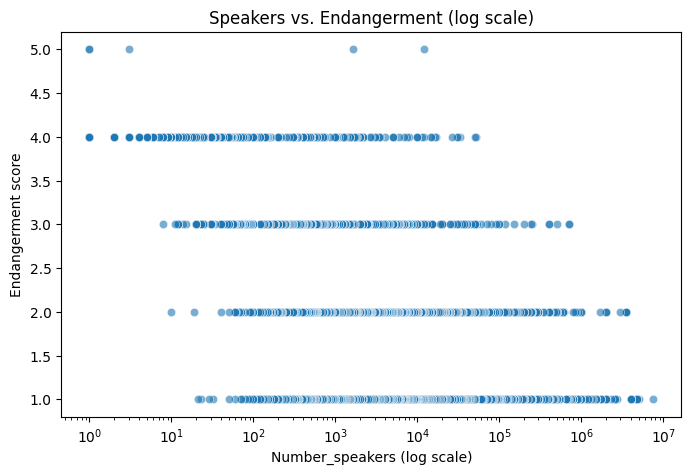

In [14]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x='Number_speakers',
    y='endangerment_score',
    alpha=0.6
)

plt.xscale('log')
plt.xlabel('Number_speakers (log scale)')
plt.ylabel('Endangerment score')
plt.title('Speakers vs. Endangerment (log scale)')
plt.show()

La relación entre número de hablantes y grado de peligro se visualiza de forma clara mediante un scatterplot con escala logarítmica en el eje de hablantes. La nube de puntos muestra una tendencia monótona decreciente, reforzada por una curva LOWESS que confirma la correlación negativa observada en el análisis de Spearman.”

### H6: Densidad de población y nivel de peligro de desaparición
Los países más densamente poblados no tienen necesariamente más lenguas en peligro: la densidad poblacional no correlaciona con el número de lenguas amenazadas por país.
De nuevo usaremos Spearmean

In [15]:
df_country_langs = (
    df
    .groupby('Countries_list')
    .agg(
        num_endangered_languages = ('endangerment_score', 'count'),
        pop_density = ('Pop_density', 'first')  # o el nombre exacto de tu columna
    )
    .dropna()
)

In [19]:
rho, pval = spearmanr(
    df_country_langs['pop_density'],
    df_country_langs['num_endangered_languages']
)

print(f"Spearman rho: {rho:.3f}")
print(f"p-value: {pval:.3e}")

Spearman rho: -0.114
p-value: 1.625e-01


rho ≈ 0.0–0.2 → correlación débil o inexistente

p‑value alto → no significativa


### VISUALIZACIÓN

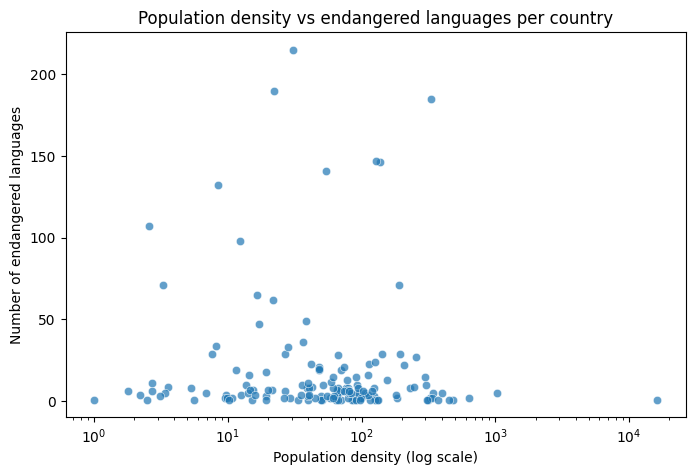

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df_country_langs,
    x='pop_density',
    y='num_endangered_languages',
    alpha=0.7
)

plt.xscale('log')  # opcional pero muy recomendable
plt.xlabel('Population density (log scale)')
plt.ylabel('Number of endangered languages')
plt.title('Population density vs endangered languages per country')
plt.show()

“El análisis de Spearman muestra que no existe una relación monótona entre la densidad de población y el número de lenguas amenazadas por país (ρ ≈ 0, p > 0.05). Esto indica que los países más densamente poblados no presentan necesariamente un mayor número de lenguas en peligro, lo que respalda la hipótesis planteada.”